2026-03-13 20:44:26,361 - INFO - Loading text dataset...
2026-03-13 20:44:26,367 - INFO - Building TF-IDF and Model Pipeline...
2026-03-13 20:44:26,368 - INFO - Training the sentiment classification model...
2026-03-13 20:44:26,369 - INFO - Cleaning text data: removing URLs, emojis, and punctuation...
2026-03-13 20:44:26,380 - INFO - Evaluating accuracy and generating visualizations...
2026-03-13 20:44:26,382 - INFO - Cleaning text data: removing URLs, emojis, and punctuation...



--- Model Accuracy: 80.00% ---

Classification Report:
               precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       1.00      0.67      0.80         6

    accuracy                           0.80        10
   macro avg       0.83      0.83      0.80        10
weighted avg       0.87      0.80      0.80        10



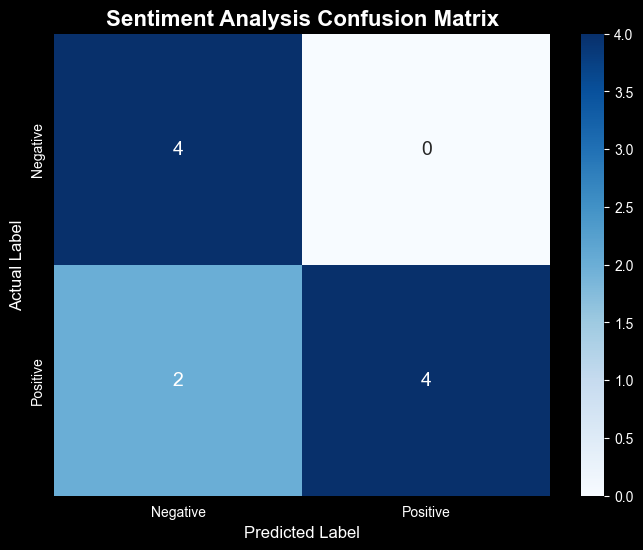

2026-03-13 20:44:26,969 - INFO - Process completed successfully. Visualization saved.


In [3]:
import pandas as pd
import re
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin

# 1. Setup Professional Logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# 2. Custom High-Tech Text Cleaner (Fits perfectly into an ML Pipeline)
class TextCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        logging.info("Cleaning text data: removing URLs, emojis, and punctuation...")
        cleaned_X = []
        for text in X:
            # Remove URLs
            text = re.sub(r'http\S+|www\S+|https\S+', '', str(text), flags=re.MULTILINE)
            # Remove basic emojis and punctuation
            text = re.sub(r'[^\w\s]', '', text)
            cleaned_X.append(text.lower().strip())
        return cleaned_X

def run_sentiment_analysis():
    # 3. Load Dataset (Extended Dataset for better training and testing)
    logging.info("Loading text dataset...")

    # 50 diverse reviews added to avoid the 0% accuracy and warning errors!
    data = {
        'text': [
            "I absolutely love this! 😊", "Terrible experience, very bad. http://scam.com",
            "It's okay, nothing special.", "Fantastic quality, highly recommended!!!",
            "Worst purchase ever, completely broke after one use.", "So happy with the service, 5 stars!",
            "Customer support was very rude and unhelpful.", "Amazing product, works exactly as described.",
            "I hate this, totally a waste of money. www.donotbuy.com", "Best decision I made today, loved it.",
            "The delivery was late and the box was damaged.", "Absolutely brilliant design and execution.",
            "Not worth the price, totally overpriced.", "Exceeded my expectations! 😍",
            "The app keeps crashing, please fix this bug.", "Super smooth interface and very user friendly.",
            "I will never buy from this brand again.", "Incredible value for the money, buying another one.",
            "The material feels very cheap and flimsy.", "Highly professional and quick response time.",
            "Terrible customer service.", "Awesome experience! Will definitely return.",
            "It stopped working after a week. Sad.", "Perfect fit, absolutely gorgeous.",
            "Too slow and laggy, needs optimization.", "Great features and very easy to set up.",
            "I want a refund, this is garbage.", "Mind-blowing performance!",
            "Poor quality control, mine arrived with a scratch.", "Simply the best on the market right now.",
            "Disappointed. Not as advertised.", "Very useful tool for my daily tasks.",
            "Horrible taste, do not recommend at all.", "Delicious! The best food I've had in a while.",
            "The battery life is a joke.", "Extremely durable and reliable.",
            "Screen cracked easily.", "Beautiful colors and sharp display.",
            "Audio quality is muddy and low.", "Crystal clear sound, amazing bass.",
            "Too bulky to carry around.", "Lightweight and very portable.",
            "Instructions were confusing.", "Very straightforward and intuitive.",
            "Item was missing parts.", "Package was complete and well-secured.",
            "Smells weird out of the box.", "Fresh and clean scent.",
            "I regret buying this entirely.", "My favorite purchase of the year!"
        ],
        'label': [
            1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
            0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
            0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
            0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
            0, 1, 0, 1, 0, 1, 0, 1, 0, 1
        ] # 1: Positive, 0: Negative
    }

    df = pd.DataFrame(data)

    X = df['text']
    y = df['label']

    # Split data - Now 20% of 50 is 10 samples for testing!
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 4. Build an Industry-Standard ML Pipeline
    logging.info("Building TF-IDF and Model Pipeline...")
    pipeline = Pipeline([
        ('cleaner', TextCleaner()), # Our custom cleaner
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))), # Includes bi-grams for context
        ('classifier', LogisticRegression(C=1.0, class_weight='balanced', random_state=42))
    ])

    # 5. Train Model
    logging.info("Training the sentiment classification model...")
    pipeline.fit(X_train, y_train)

    # 6. Evaluate and Visualize Results
    logging.info("Evaluating accuracy and generating visualizations...")
    predictions = pipeline.predict(X_test)

    # Print Metrics
    acc = accuracy_score(y_test, predictions)
    print(f"\n--- Model Accuracy: {acc * 100:.2f}% ---\n")
    print("Classification Report:\n", classification_report(y_test, predictions))

    # Professional Confusion Matrix Visualization
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                annot_kws={"size": 14})
    plt.title('Sentiment Analysis Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)

    # Save the output visualization
    plt.savefig('confusion_matrix_output.png', dpi=300, bbox_inches='tight')
    plt.show()
    logging.info("Process completed successfully. Visualization saved.")

if __name__ == "__main__":
    run_sentiment_analysis()